# Mouse Brain Spatial Multi-omics

## Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import torch
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.multiomics import build_spatially_regularized_connectivity
from SpaDiff.utils import adjust_louvain_resolution, set_seed

In [4]:
SEED = 42
N_CLUSTERS = 14
N_LATENT = 50
N_HVG = 3000
MIN_CELLS = 10
DROP_ATAC_DEPTH_COMPONENT = True
N_NEIGHBORS = 7
LATENT_NEIGHBORS = 10
TRAINING_EPOCHS = 1000
MAX_ORDER = 2
SIMPLEX_ORDERS = tuple(range(1, MAX_ORDER + 1))

DSM_LOSS_WEIGHT = 1.0
TECHNICAL_LOSS_WEIGHT = 0.0
PRIOR_KL_LOSS_WEIGHT = 0.0

DATA_ROOT = Path("E:/gxy_2/final/0_data/case4/")
RNA_FILE = DATA_ROOT / "RNA.h5ad"
ATAC_FILE = DATA_ROOT / "ATAC.h5ad"

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda:0


## Paired data

In [5]:
adata_rna = sc.read_h5ad(RNA_FILE)
adata_atac = sc.read_h5ad(ATAC_FILE)
adata_rna.var_names_make_unique()
adata_atac.var_names_make_unique()

common_spots = adata_rna.obs_names[adata_rna.obs_names.isin(adata_atac.obs_names)]
if len(common_spots) == 0:
    raise ValueError("RNA and ATAC contain no matching spot names.")
if len(common_spots) != adata_rna.n_obs or len(common_spots) != adata_atac.n_obs:
    print(
        f"Keeping {len(common_spots):,} shared spots; "
        f"dropping RNA={adata_rna.n_obs-len(common_spots):,}, "
        f"ATAC={adata_atac.n_obs-len(common_spots):,}."
    )
adata_rna = adata_rna[common_spots].copy()
adata_atac = adata_atac[common_spots].copy()
assert np.array_equal(adata_rna.obs_names, adata_atac.obs_names)

rna_spatial = np.asarray(adata_rna.obsm["spatial"], dtype=np.float64)
atac_spatial = np.asarray(adata_atac.obsm["spatial"], dtype=np.float64)
if not np.allclose(rna_spatial, atac_spatial, rtol=1e-5, atol=1e-5):
    maximum = np.max(np.abs(rna_spatial - atac_spatial))
    raise ValueError(
        f"Paired spatial coordinates differ; maximum difference={maximum:.6g}."
    )
print(f"paired spots = {adata_rna.n_obs:,}")

paired spots = 9,215


## Preprocessing

In [6]:
sc.pp.filter_genes(adata_rna, min_cells=MIN_CELLS)
adata_rna.layers["counts"] = adata_rna.X.copy()
sc.pp.highly_variable_genes(
    adata_rna,
    flavor="seurat_v3",
    layer="counts",
    n_top_genes=N_HVG,
)
adata_rna = adata_rna[:, adata_rna.var["highly_variable"]].copy()
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna, max_value=10)
sc.tl.pca(
    adata_rna,
    n_comps=N_LATENT,
    svd_solver="arpack",
    random_state=SEED,
)

X_atac_lsi_np, atac_lsi_diagnostics = sd.robust_atac_lsi(
    adata_atac,
    n_components=N_LATENT,
    min_cells=MIN_CELLS,
    drop_depth_component=DROP_ATAC_DEPTH_COMPONENT,
    random_state=SEED,
)

X_rna_np = StandardScaler().fit_transform(
    np.asarray(adata_rna.obsm["X_pca"], dtype=np.float32)
).astype(np.float32)
X_atac_np = StandardScaler().fit_transform(X_atac_lsi_np).astype(np.float32)
if X_rna_np.shape != X_atac_np.shape:
    raise ValueError(
        f"Paired feature shapes differ: RNA={X_rna_np.shape}, ATAC={X_atac_np.shape}."
    )

adata_rna.obsm["X_rna_pca_scaled"] = X_rna_np
adata_rna.obsm["X_atac_lsi_scaled"] = X_atac_np
adata_atac.obsm["X_lsi"] = X_atac_np
X_joint_np = np.concatenate((X_rna_np, X_atac_np), axis=1).astype(np.float32)

print("RNA PCA shape =", X_rna_np.shape)
print("ATAC LSI shape =", X_atac_np.shape)
print("selected ATAC peaks =", atac_lsi_diagnostics["n_selected_peaks"])
print("removed depth component =", atac_lsi_diagnostics["depth_component"])
print("joint feature shape =", X_joint_np.shape)

RNA PCA shape = (9215, 50)
ATAC LSI shape = (9215, 50)
selected ATAC peaks = 121068
removed depth component = 0
joint feature shape = (9215, 100)


## Spatial topology

In [7]:
spatial_topology = sd.build_spatial_topology(
    adata_rna,
    mode="global_knn",
    n_neighbors=N_NEIGHBORS,
    max_order=MAX_ORDER,
    device=device,
)
adjacency = spatial_topology.adjacency
base_operators = spatial_topology.operators
print("simplex counts =", spatial_topology.simplex_counts)
print("average degree =", adjacency.nnz / adjacency.shape[0])

Simplicial complex statistics:
  order 0 (vertices): 9,215
  order 1 (edges): 32,320
  order 2 (triangles): 28,252
simplex counts = {0: 9215, 1: 32320, 2: 28252}
average degree = 7.014650027129679


## SpaDiff training

In [8]:
config = sd.SpaDiffConfig(
    data_dim=2 * N_LATENT,
    condition_input_dim=2 * N_LATENT,
    num_batches=1,
    num_modalities=1,
    num_scales=1000,
    topology_hidden_dim=128,
    topology_dim=64,
    hidden_dim=128,
    simplex_orders=SIMPLEX_ORDERS,
    propagation_steps=5,
    propagation_alpha=0.25,
    dropout=0.05,
    topology_projection_dropout=0.05,
    topology_residual=False,
    learnable_propagation=False,
    topology_output_normalization="feature",
    dsm_weighting="variance",
    dsm_weight=DSM_LOSS_WEIGHT,
    batch_alignment_weight=TECHNICAL_LOSS_WEIGHT,
    batch_posterior_weight=1.0,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
    batch_balanced_loss=True,
)
model = sd.SpaDiff(config).to(device)
adata_rna = model.fit_transform(
    adata_rna,
    X_joint_np,
    base_operators,
    batch_key=None,
    topology_key="spadiff",
    harmonized_key="X_spadiff",
    epochs=TRAINING_EPOCHS,
    learning_rate=5e-4,
    weight_decay=1e-4,
    ema_decay=0.999,
    progress=True,
)
training = model.training_result_
print("best loss =", training.best_loss, "at epoch", training.best_epoch)
print("last DSM loss =", training.dsm_losses[-1])
print("topology shape =", adata_rna.obsm["spadiff"].shape)

Training SpaDiff: 100%|██████████| 1000/1000 [00:31<00:00, 31.98epoch/s]


best loss = 0.23321542143821716 at epoch 968
last DSM loss = 0.23953549563884735
topology shape = (9215, 64)


In [9]:
rna_correlation = np.mean(np.abs(np.corrcoef(
    adata_rna.obsm["spadiff"].T, X_rna_np.T
)[:config.topology_dim, config.topology_dim:]))
atac_correlation = np.mean(np.abs(np.corrcoef(
    adata_rna.obsm["spadiff"].T, X_atac_np.T
)[:config.topology_dim, config.topology_dim:]))
print(f"mean |corr| with RNA latent = {rna_correlation:.3f}")
print(f"mean |corr| with ATAC latent = {atac_correlation:.3f}")

mean |corr| with RNA latent = 0.081
mean |corr| with ATAC latent = 0.079


## Spatial domains

In [ ]:
joint_connectivities = build_spatially_regularized_connectivity(
    adata_rna,
    adjacency,
    use_rep="spadiff",
    n_neighbors=LATENT_NEIGHBORS,
    latent_weight=0.40,
    spatial_weight=0.60,
    random_state=SEED,
    neighbors_key="spadiff",
    output_key="spadiff_spatial_connectivities",
)
adata_rna = adjust_louvain_resolution(
    adata_rna,
    target_n_clusters=N_CLUSTERS,
    use_rep="spadiff",
    key_added="louvain",
    n_neighbors=LATENT_NEIGHBORS,
    random_state=SEED,
    resolution_bounds=(0.01, 5.0),
    tolerance=0,
    max_iterations=25,
    verbose=True,
    clustering_kwargs={"adjacency": joint_connectivities},
)
adata_rna.obsm["spatial"] = np.column_stack((-rna_spatial[:, 1], rna_spatial[:, 0]))

Adjusting Louvain toward 14 clusters.
Searching resolution in [0.01, 5] for 14 clusters...
  resolution=0.01 -> 1 clusters (target=14)
  resolution=5 -> 68 clusters (target=14)
  resolution=2.505 -> 18 clusters (target=14)
  resolution=1.2575 -> 10 clusters (target=14)
  resolution=1.88125 -> 15 clusters (target=14)
  resolution=1.56937 -> 13 clusters (target=14)
  resolution=1.72531 -> 13 clusters (target=14)
  resolution=1.80328 -> 15 clusters (target=14)
  resolution=1.7643 -> 13 clusters (target=14)
  resolution=1.78379 -> 14 clusters (target=14)
Selected resolution=1.78379: 14 clusters (target reached).


In [62]:
plot_color = ["#6D1A9C","#A52A2A","#7495D3","#D1D1D1","#59BE86","#489248","#FEB915",
              "#C798EE","#4968BB","#008080","#FF8C42","#B8877D","#F56867","#E377C2"]

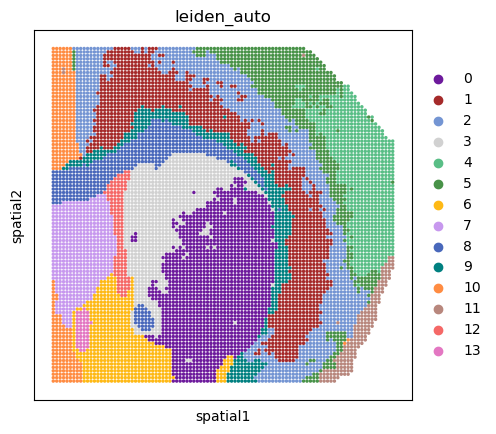

In [ ]:
sc.pl.spatial(adata_rna, color="louvain", spot_size=1, palette=plot_color)